**PROJETO 1**

In [24]:
import math
import pandas as pd
import numpy as np

**Variável com a planilha**

In [5]:
arquivo = 'Dados Habitacionais de Ames.xlsx'

**Datasheet da planilha**

Pra editar no python

In [8]:
df = pd.read_excel(arquivo)

**Classificação das variáveis**
- Sale Price (Preço de venda) - quantitativo contínuo
- Lot area (Área do lote) - quantitativo contínuo
- neighborhood (bairro) - qualitativo nominal

**Contexto**

Nos somos uma corretora de imoveis, afim de melhorar a eficiência do nosso trabalho e providenciar um serviço mais preciso, utilizando o nosso banco de dados  uma pesquisa de mercado para categorizar os nossos imoveis em preço, área do lote e Bairro, para obter as melhores tendências do mercado imobiliario.

**BAIRRO**

In [9]:
df1 = df.Neighborhood.value_counts()
df1

,count
Neighborhood,
NAmes,443
CollgCr,267
OldTown,239
Edwards,194
Somerst,182
NridgHt,166
Gilbert,165
Sawyer,151
NWAmes,131


**CONVERTER DADOS PARA DATAFRAME**

In [10]:
dadosvquali = pd.DataFrame(df1)
dadosvquali = dadosvquali.rename(columns={'count': 'Frequência absoluta'})
dadosvquali

,Frequência absoluta
Neighborhood,
NAmes,443
CollgCr,267
OldTown,239
Edwards,194
Somerst,182
NridgHt,166
Gilbert,165
Sawyer,151
NWAmes,131


**TOTAL DOS DADOS**

Temos 2930 linhas

In [11]:
Totalcasas = df1.sum()
Totalcasas

np.int64(2930)

**FREQUÊNCIA RELATIVA USANDO O TOTAL DE CASAS**

In [12]:
dadosvquali["Frequência %"]=round(dadosvquali['Frequência absoluta']*100/Totalcasas,2)
dadosvquali

,Frequência absoluta,Frequência %
Neighborhood,,
NAmes,443,15.12
CollgCr,267,9.11
OldTown,239,8.16
Edwards,194,6.62
Somerst,182,6.21
NridgHt,166,5.67
Gilbert,165,5.63
Sawyer,151,5.15
NWAmes,131,4.47


**Montando tabela de frequência Acumulada e Acumulada (%)**

In [28]:
freqacum=np.cumsum(dadosvquali.sort_index())
freqacum

,Frequência absoluta,Frequência %
Neighborhood,,
Blmngtn,28,0.96
Blueste,38,1.30
BrDale,68,2.32
BrkSide,176,6.01
ClearCr,220,7.51
CollgCr,487,16.62
Crawfor,590,20.14
Edwards,784,26.76
Gilbert,949,32.39


**Gerando a Tabela completa**

In [32]:
coluna = 'Neighborhood'
dist_freq = pd.DataFrame({
    'Frequência': dadosvquali['Frequência absoluta'],
    'Frequência Relativa (%)': dadosvquali['Frequência %'],
    'Freq.Acum.': freqacum['Frequência absoluta'],
    'Freq.Rel.Acum. (%)': freqacum['Frequência %']
})
dist_freq = round(dist_freq, 2)
print(dist_freq)
print(f'\n      Variável:{coluna}')
print('     *Limites superiores do intervalo de classes não incluídos')

              Frequência  Frequência Relativa (%)  Freq.Acum.  \
Neighborhood                                                    
Blmngtn               28                     0.96          28   
Blueste               10                     0.34          38   
BrDale                30                     1.02          68   
BrkSide              108                     3.69         176   
ClearCr               44                     1.50         220   
CollgCr              267                     9.11         487   
Crawfor              103                     3.52         590   
Edwards              194                     6.62         784   
Gilbert              165                     5.63         949   
Greens                 8                     0.27         957   
GrnHill                2                     0.07         959   
IDOTRR                93                     3.17        1052   
Landmrk                1                     0.03        1053   
MeadowV               37 

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

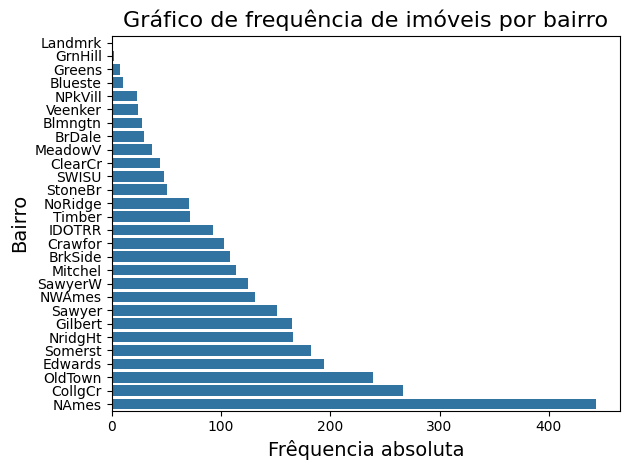

In [14]:
neighborhood_ordem = df['Neighborhood'].value_counts().sort_values(ascending=True).index
sns.countplot(y='Neighborhood', data=df, order=neighborhood_ordem)
plt.title('Gráfico de frequência de imóveis por bairro',size=16)
plt.xlabel('Frêquencia absoluta',size=14)
plt.ylabel('Bairro',size=14)
plt.tight_layout()
plt.show()

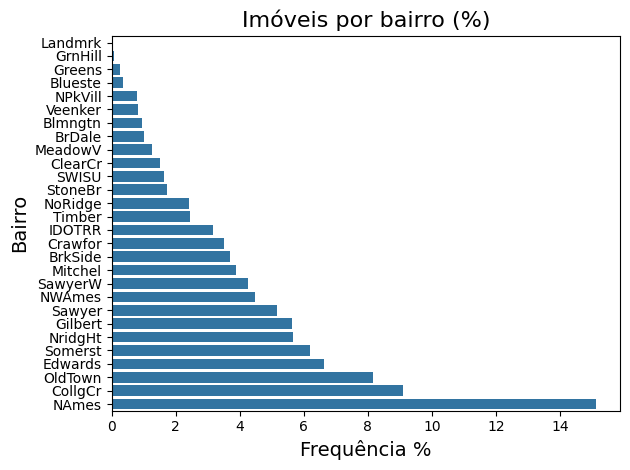

In [15]:
dados = dadosvquali.sort_values('Frequência %')

sns.barplot(x='Frequência %', y=dados.index, data=dados)

plt.title('Imóveis por bairro (%)',size=16)
plt.xlabel('Frequência %',size=14)
plt.ylabel('Bairro',size=14)

plt.tight_layout()
plt.show()

Regra de sturges para descobrir numero de intervalos do histograma

In [16]:
math.ceil(1+3.322*math.log10(len(df)))

13

In [17]:
df2 = df.SalePrice.value_counts(bins=13 , sort=False)
df2

,count
"(12046.788, 69882.154]",51
"(69882.154, 126975.308]",600
"(126975.308, 184068.462]",1200
"(184068.462, 241161.615]",578
"(241161.615, 298254.769]",261
"(298254.769, 355347.923]",124
"(355347.923, 412441.077]",64
"(412441.077, 469534.231]",28
"(469534.231, 526627.385]",9
"(526627.385, 583720.538]",7


In [18]:
dadosvquanti = pd.DataFrame(df2)
dadosvquanti = dadosvquanti.rename(columns={'count': 'Frequência absoluta'})
dadosvquanti['Frequência %'] = round(dadosvquanti['Frequência absoluta']*100/Totalcasas,2)
dadosvquanti

,Frequência absoluta,Frequência %
"(12046.788, 69882.154]",51,1.74
"(69882.154, 126975.308]",600,20.48
"(126975.308, 184068.462]",1200,40.96
"(184068.462, 241161.615]",578,19.73
"(241161.615, 298254.769]",261,8.91
"(298254.769, 355347.923]",124,4.23
"(355347.923, 412441.077]",64,2.18
"(412441.077, 469534.231]",28,0.96
"(469534.231, 526627.385]",9,0.31
"(526627.385, 583720.538]",7,0.24


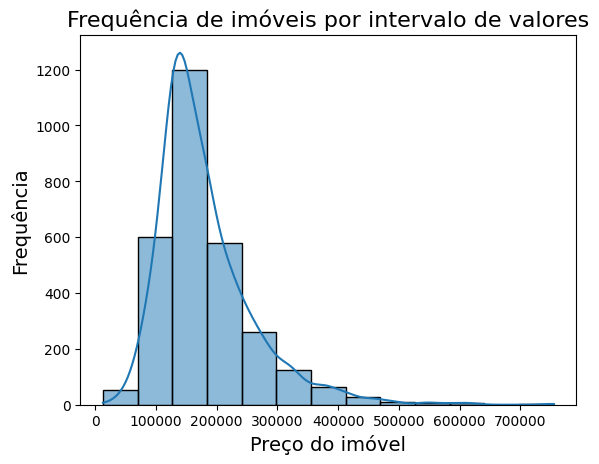

In [19]:
sns.histplot(df.SalePrice, bins=13, kde=True)

plt.title('Frequência de imóveis por intervalo de valores',size=16)
plt.xlabel('Preço do imóvel',size=14)
plt.ylabel('Frequência',size=14)

plt.show()

In [20]:
df3 = df['Lot Area'].value_counts(bins=13, sort=False)
df3

,count
"(1086.054, 17757.308]",2804
"(17757.308, 34214.615]",98
"(34214.615, 50671.923]",16
"(50671.923, 67129.231]",7
"(67129.231, 83586.538]",1
"(83586.538, 100043.846]",0
"(100043.846, 116501.154]",1
"(116501.154, 132958.462]",0
"(132958.462, 149415.769]",0
"(149415.769, 165873.077]",2


In [21]:
dadosvquanti2 = pd.DataFrame(df3)
dadosvquanti2 = dadosvquanti2.rename(columns={'count': 'Frequência absoluta'})
dadosvquanti2['Frequência %'] = round(dadosvquanti2['Frequência absoluta']*100/Totalcasas,2)
dadosvquanti2

,Frequência absoluta,Frequência %
"(1086.054, 17757.308]",2804,95.70
"(17757.308, 34214.615]",98,3.34
"(34214.615, 50671.923]",16,0.55
"(50671.923, 67129.231]",7,0.24
"(67129.231, 83586.538]",1,0.03
"(83586.538, 100043.846]",0,0.00
"(100043.846, 116501.154]",1,0.03
"(116501.154, 132958.462]",0,0.00
"(132958.462, 149415.769]",0,0.00
"(149415.769, 165873.077]",2,0.07


Text(0, 0.5, 'Frequência')

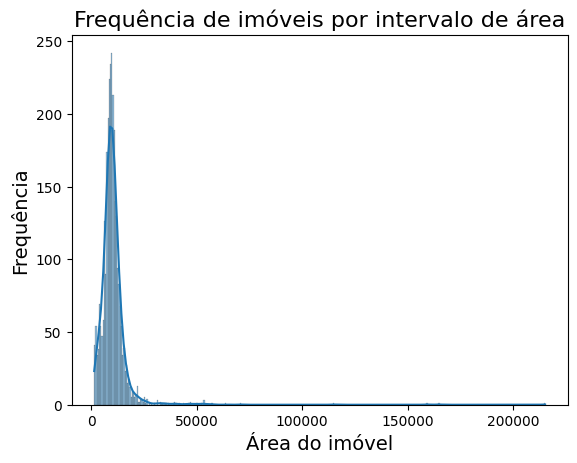

In [ ]:
sns.histplot(df['Lot Area'], kde=True)

plt.title('Frequência de imóveis por intervalo de área',size=16)
plt.xlabel('Área do imóvel',size=14)
plt.ylabel('Frequência',size=14)

Os intervalos ficaram ruins por conta dos outliers, devemos retiralos e descobrir os limites sem eles através dos quartis

In [ ]:
Q1 = df['Lot Area'].quantile(.25)
Q3 = df['Lot Area'].quantile(.75)
IIQ = Q3 - Q1
limite_inferior = Q1 - 1.5 * IIQ
limite_superior = Q3 + 1.5 * IIQ

In [ ]:
quartis = pd.DataFrame([Q1, Q3, IIQ, limite_inferior, limite_superior], index=['Q1', 'Q3', 'IIQ', 'Limite inferior', 'Limite superior'], columns=['Valores'])
quartis

,Valores
Q1,7440.25
Q3,11555.25
IIQ,4115.00
Limite inferior,1267.75
Limite superior,17727.75


Text(0, 0.5, 'Frequência')

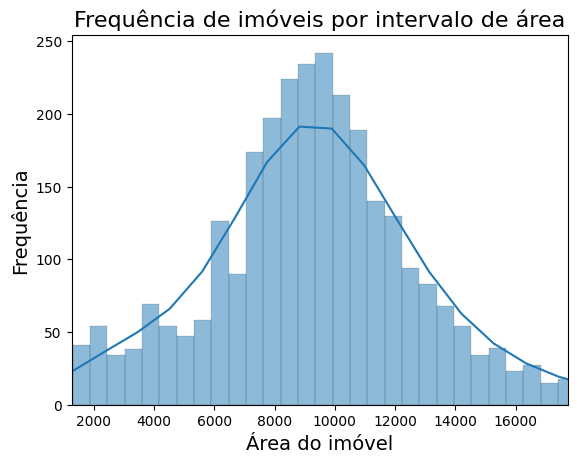

In [ ]:
sns.histplot(df['Lot Area'], kde=True)
plt.xlim(limite_inferior, limite_superior)
plt.title('Frequência de imóveis por intervalo de área',size=16)
plt.xlabel('Área do imóvel',size=14)
plt.ylabel('Frequência',size=14)

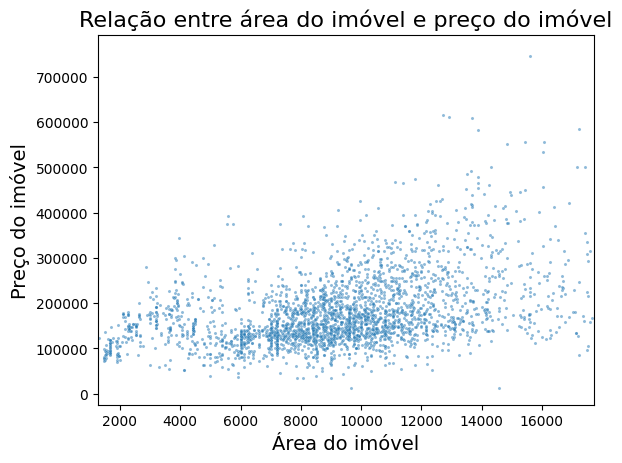

In [ ]:
sns.scatterplot(x='Lot Area', y='SalePrice', data=df, alpha=0.5, s=5)
plt.xlim(limite_inferior, limite_superior)
plt.title('Relação entre área do imóvel e preço do imóvel',size=16)
plt.xlabel('Área do imóvel',size=14)
plt.ylabel('Preço do imóvel',size=14)

plt.show()

Podemos ver que a coorenlação entre o tamanho do imóvel e o preço dele tem uma relação fraca (os pontos ficam dispersos)


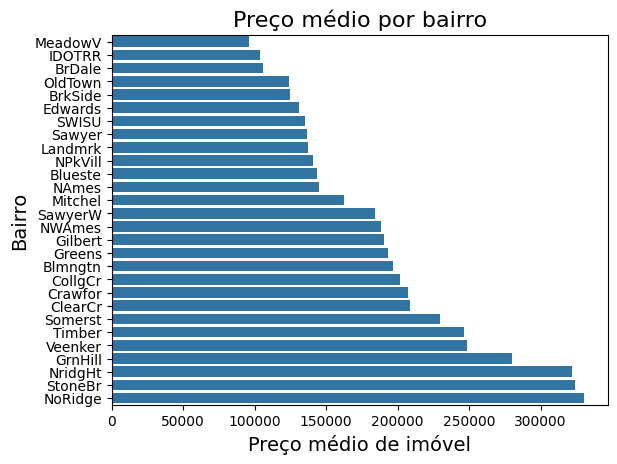

In [ ]:
media = df.groupby('Neighborhood')['SalePrice'].mean().sort_values()

sns.barplot(y=media.index, x=media)

plt.title('Preço médio por bairro',size=16)
plt.ylabel('Bairro',size=14)
plt.xlabel('Preço médio de imóvel',size=14)

plt.show()

Medidas resumo do valor de venda:
Média e Amplitude

In [ ]:
print('Média de preços:',df['SalePrice'].mean())
print('Amplitude de preços:',df['SalePrice'].max()-df['SalePrice'].min())

Média de preços: 180796.0600682594
Amplitude de preços: 742211


Medidas resumo da área: Média e Amplitude

In [ ]:
print('Média de área:',df['Lot Area'].mean())
print('Amplitude de área:',df['Lot Area'].max()-df['Lot Area'].min())

Média de área: 10147.921843003413
Amplitude de área: 213945


Medidas resumo do bairro: Moda e

In [ ]:
print('Moda:', df1.idxmax(), '| Frequência: ',df1.max())


Moda: NAmes | Frequência:  443
